In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

In [4]:
df_copy = df.copy()

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df[df['country']=='India']

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
39,s40,TV Show,Chhota Bheem,NaN,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,"September 16, 2021",2021,TV-Y7,3 Seasons,Kids' TV,"A brave, energetic little boy with superhuman ..."
50,s51,TV Show,Dharmakshetra,NaN,"Kashmira Irani, Chandan Anand, Dinesh Mehta, A...",India,"September 15, 2021",2014,TV-PG,1 Season,"International TV Shows, TV Dramas, TV Sci-Fi &...","After the ancient Great War, the god Chitragup..."
66,s67,TV Show,Raja Rasoi Aur Anya Kahaniyan,NaN,NaN,India,"September 15, 2021",2014,TV-G,1 Season,"Docuseries, International TV Shows",Explore the history and flavors of regional In...
...,...,...,...,...,...,...,...,...,...,...,...,...
8773,s8774,Movie,Yanda Kartavya Aahe,Kedar Shinde,"Ankush Choudhary, Smita Shewale, Mohan Joshi, ...",India,"January 1, 2018",2006,TV-PG,151 min,"Comedies, Dramas, International Movies",Thanks to an arranged marriage that was design...
8775,s8776,TV Show,Yeh Meri Family,NaN,"Vishesh Bansal, Mona Singh, Akarsh Khurana, Ah...",India,"August 31, 2018",2018,TV-PG,1 Season,"International TV Shows, TV Comedies","In the summer of 1998, middle child Harshu bal..."
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,"December 31, 2019",2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...
8799,s8800,Movie,Zenda,Avadhoot Gupte,"Santosh Juvekar, Siddharth Chandekar, Sachit P...",India,"February 15, 2018",2009,TV-14,120 min,"Dramas, International Movies",A change in the leadership of a political part...


In [7]:
df[df['country']=='India'].sample(18)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3268,s3269,Movie,House Arrest,"Shashanka Ghosh, Samit Basu","Ali Fazal, Shriya Pilgaonkar, Jim Sarbh, Barkh...",India,"November 15, 2019",2019,TV-14,105 min,"Comedies, Independent Movies, International Mo...",A world-weary man’s self-imposed home confinem...
6055,s6056,Movie,A Scandall,Ishaan Trivedi,"Johnny Baweja, Reeth Mazumder, Manav Kaul, Tan...",India,"October 15, 2017",2016,TV-MA,108 min,"International Movies, Thrillers",A film school graduate is interested in making...
195,s196,Movie,EMI: Liya Hai To Chukana Padega,Saurabh Kabra,"Sanjay Dutt, Arjun Rampal, Malaika Arora, Aash...",India,"August 27, 2021",2008,TV-14,128 min,"Comedies, Dramas, International Movies",A bank hires an enigmatic and unorthodox debt ...
1678,s1679,Movie,Raman Raghav 2.0,Anurag Kashyap,"Nawazuddin Siddiqui, Vicky Kaushal, Sobhita Dh...",India,"November 19, 2020",2016,TV-MA,133 min,"International Movies, Thrillers",A corrupt cop and a serial killer obsessed wit...
199,s200,Movie,Koi Aap Sa,Partho Mitra,"Aftab Shivdasani, Natassha, Dipannita Sharma, ...",India,"August 27, 2021",2006,TV-14,135 min,"Comedies, Dramas, International Movies",Star athlete Rohan has his eye on a beautiful ...
3201,s3202,Movie,Thug Life,Mukesh Vohra,"Harish Verma, Jass Bajwa, Rajiv Thakur, Ihana ...",India,"December 1, 2019",2017,TV-14,133 min,"Comedies, Dramas, International Movies",A get-rich-quick scheme goes awry when a group...
8149,s8150,Movie,Tamanchey,Navneet Behal,"Nikhil Dwivedi, Richa Chadha, Damandeep Singh ...",India,"October 15, 2017",2014,TV-MA,111 min,"Action & Adventure, International Movies, Roma...",A man and a woman on the run from the law are ...
7827,s7828,Movie,Ram Teri Ganga Maili,Raj Kapoor,"Mandakini, Rajiv Kapoor, Divya Rana, Saeed Jaf...",India,"December 31, 2019",1985,TV-14,178 min,"Classic Movies, Dramas, International Movies",Abandoned by her new husband and father of her...
253,s254,Movie,Bombay,Mani Ratnam,"Arvind Swamy, Manisha Koirala, Nasser, Raja Kr...",India,"August 18, 2021",1995,TV-14,135 min,"Dramas, International Movies, Romantic Movies",Years after they elope against their family’s ...
6150,s6151,Movie,An American in Madras,Karan Bali,NaN,India,"January 1, 2017",2013,TV-PG,80 min,"Documentaries, International Movies",Extensive film clips and interviews tell the s...


In [8]:
df[df['release_year'] == 1943]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8660,s8661,Movie,Undercover: How to Operate Behind Enemy Lines,John Ford,NaN,United States,"March 31, 2017",1943,TV-PG,61 min,"Classic Movies, Documentaries",This World War II-era training film dramatizes...
8739,s8740,Movie,Why We Fight: The Battle of Russia,"Frank Capra, Anatole Litvak",NaN,United States,"March 31, 2017",1943,TV-PG,82 min,Documentaries,This installment of Frank Capra's acclaimed do...
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...


In [9]:
df.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

In [10]:
len(df.columns)

12

In [11]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [12]:
df[df['title'] == 'Shutter Island']['description']

1358    A U.S. marshal's troubling visions compromise ...
Name: description, dtype: object

In [13]:
type(df[df['title'] == 'Shutter Island']['description'])

pandas.core.series.Series

In [14]:
df[df['title'] == 'Shutter Island']['description'][1358]

"A U.S. marshal's troubling visions compromise his investigation into the disappearance of a patient from a hospital for the criminally insane."

In [15]:
df.shape

(8807, 12)

Check for null values

In [16]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [17]:
len(df)

8807

In [18]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
# df.dropna()
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [21]:
df['date_added']

0       September 25, 2021
1       September 24, 2021
2       September 24, 2021
3       September 24, 2021
4       September 24, 2021
               ...        
8802     November 20, 2019
8803          July 1, 2019
8804      November 1, 2019
8805      January 11, 2020
8806         March 2, 2019
Name: date_added, Length: 8807, dtype: object

In [22]:
type(df['date_added'])

pandas.core.series.Series

In [23]:
type(df['date_added'][0])

str

In [24]:
df['date_added'] = df['date_added'].str.strip()

In [25]:
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y')

In [26]:
df['date_added']

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[ns]

In [27]:
df['day_added'] = df['date_added'].dt.day
df['month_added'] = df['date_added'].dt.day
df['year_added'] = df['date_added'].dt.day

In [28]:
df['day_added']

0       25.0
1       24.0
2       24.0
3       24.0
4       24.0
        ... 
8802    20.0
8803     1.0
8804     1.0
8805    11.0
8806     2.0
Name: day_added, Length: 8807, dtype: float64

In [29]:
df['month_added']

0       25.0
1       24.0
2       24.0
3       24.0
4       24.0
        ... 
8802    20.0
8803     1.0
8804     1.0
8805    11.0
8806     2.0
Name: month_added, Length: 8807, dtype: float64

In [30]:
df['year_added']

0       25.0
1       24.0
2       24.0
3       24.0
4       24.0
        ... 
8802    20.0
8803     1.0
8804     1.0
8805    11.0
8806     2.0
Name: year_added, Length: 8807, dtype: float64

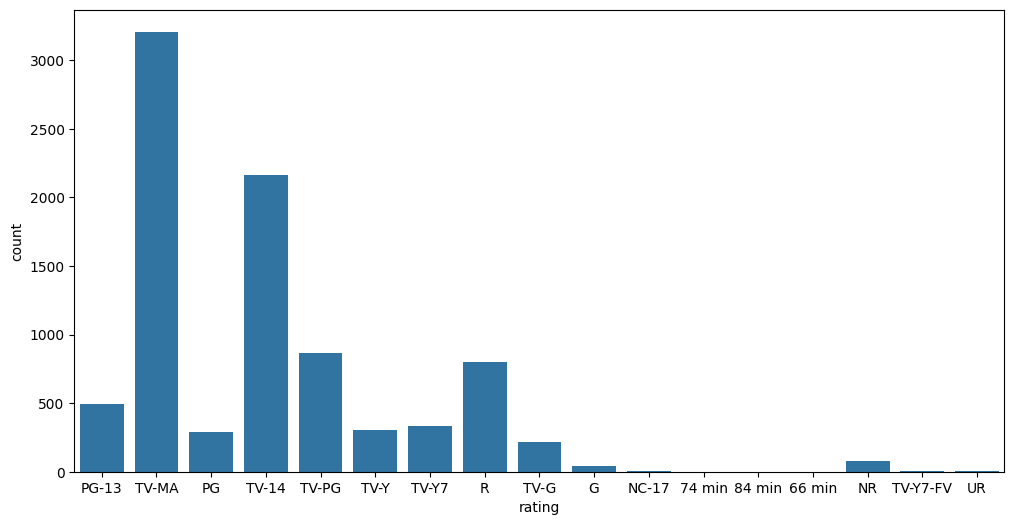

In [31]:
plt.figure(figsize=(12,6))
sns.countplot(x='rating',data=df)
plt.show()

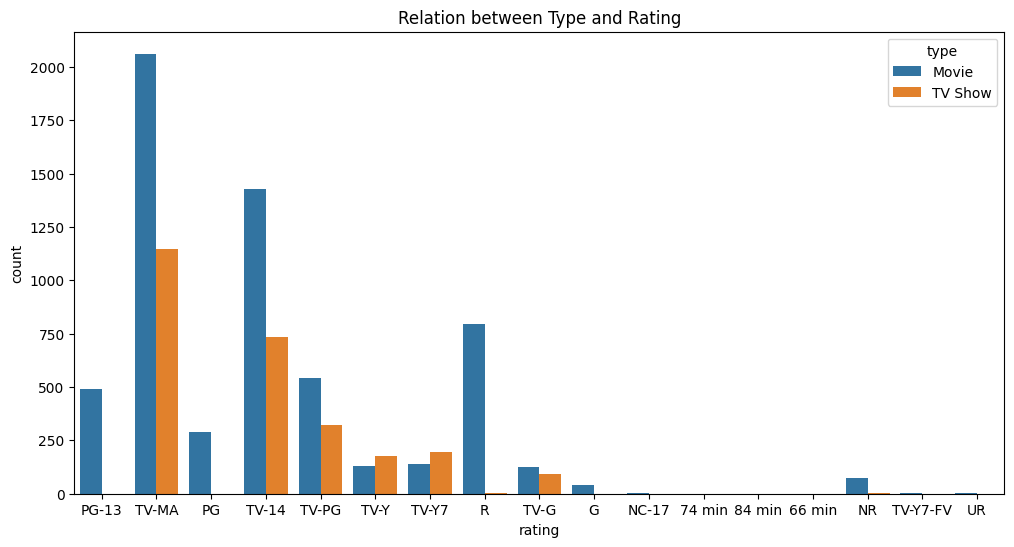

In [32]:
plt.figure(figsize=(12,6))
sns.countplot(x='rating',hue='type', data=df)
plt.title('Relation between Type and Rating')
plt.show()

Piechart for rating

[]

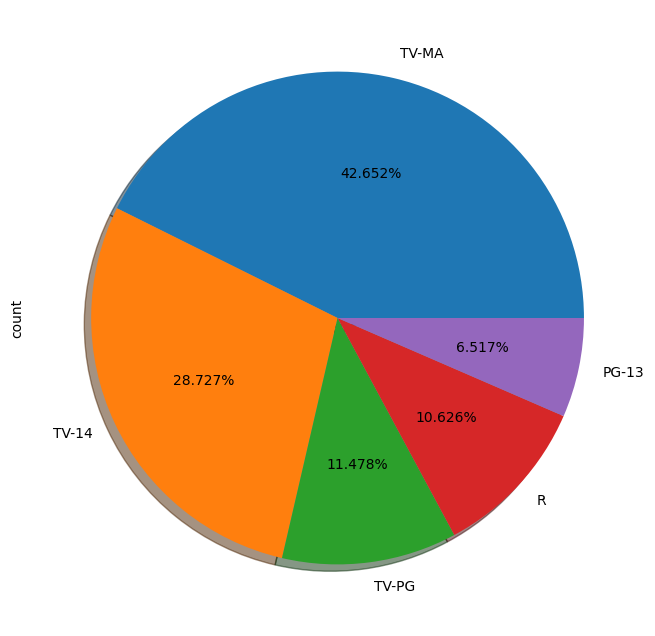

In [33]:
df['rating'].value_counts().head().plot.pie(autopct="%1.3f%%", shadow=True, figsize=(10,8))
plt.plot()